<div class="usecase-header-bar">
  <div class="usecase-title">Spot Parking Problems: Identifying Off-Street Parking Shortfalls in the City of Melbourne</div>
  <img class="usecase-logo" src="{logo_url}" alt="MOP Logo" />
</div>

<div class="usecase-authors"><b>Authored by: </b> Tithra Chap</div>

<div class="usecase-duration"><b>Duration:</b> 120 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, pandas, basic statistics (linear regression), and ipywidgets</div>
</div>

<div class="usecase-section-header" id="contents">Contents</div>

- [Scenario](#scenario)
- [What this use case will teach you](#teaches)
- [Background](#background)
- [Data Sets](#datasets)
- [Key Takeaways](#key-takeaways)
- [1. Explore the datasets](#explore)
- [2. Clean and merge the datasets](#clean)
- [3. Build analysis model](#model)
- [4. Visualise the analytical results](#visualise)
- [5. Develop interactivity](#interactivity)
- [Demo use case](#demo)

<div class="usecase-section-header" id="scenario">Scenario</div>

As a **city planner at the City of Melbourne**, I want to identify city blocks where residential dwellings and employment are growing faster than off-street parking supply, so that I can prioritise those blocks for public transportation investment instead of building more parking.

The City of Melbourne has always evolved, and so have the numbers of its residential dwellings and employment population (based on data available on Melbourne Open Data). Without a consistent or parallel increase in off-street parking, the city will face difficulty in providing enough parking spaces for private transportation. To resolve this problem, city planners need to locate the potential areas where an extension of public transportation should be implemented to replace the need for off-street parking. CLUE datasets contain information on employment, residential dwellings and parking spots in the city blocks. By tracking the number of employees and residential dwellings in the city blocks and analysing their trends alongside the number of off-street parking spaces, we can identify the blocks that a city planner should pay closer attention to, and ensure that public transportation is sufficient to handle the daily commuting traffic.

<div class="usecase-section-header" id="teaches">What this use case will teach you</div>

This case study is intended to provide educational instructions on how to use CLUE datasets (Employment by block, Residential dwellings by block, and Off-street parking by block) to resolve the analytical problem above.

The key learnings are:

- How to explore the CLUE datasets
- How to clean and merge those CLUE datasets
- How to build a linear regression model for this use case
- How to evaluate a regression model using R² and MAE
- How to use *ipywidgets* to implement interactivity
- How to link a visualisation with *ipywidgets*

NOTE: This use case provides interactive tools so that the user can experience the interaction with the data, as well as learning how to use it.

<p class="usecase-subsection-header">Walkthrough steps:</p>

1. Explore the THREE datasets
2. Clean and merge them
3. Build the analysis model
4. Visualise the analytical results
5. Develop interactivity

<div class="usecase-section-header" id="background">Background</div>

The City of Melbourne conducts a comprehensive bi-annual survey of its residents and businesses called the "Census of Land Use and Employment (CLUE)". CLUE captures key information on land use, employment, and economic activity across the City of Melbourne.

CLUE data assists the City of Melbourne's business planning, policy development and strategic decision making. Investors, consultants, students, urban researchers, property analysts, businesses and developers can take advantage of CLUE to understand customers, the marketplace and the changing form and nature of the city.

NOTE: we suggest scanning through the data dictionaries of the datasets below at Melbourne Open Data to familiarise yourself with them beforehand.

<p class="usecase-subsection-header" id="datasets">Data Sets</p>

This use case employs THREE datasets available on the Melbourne Open Data website:

- [Residential Dwellings Dataset](https://data.melbourne.vic.gov.au/explore/dataset/residential-dwellings/)
- [Employment by city blocks](https://data.melbourne.vic.gov.au/explore/dataset/employment-by-block-by-anzsic/table/)
- [Off-street car parking](https://data.melbourne.vic.gov.au/explore/dataset/off-street-car-parks-with-capacity-and-type/)

The [CLUE blocks](https://data.melbourne.vic.gov.au/explore/dataset/blocks-for-census-of-land-use-and-employment-clue/table/) map is also used for location visualisation.

<div class="usecase-section-header" id="key-takeaways">Key Takeaways</div>

<div class="usecase-key-takeaways">

- Employment and residential dwelling counts both show a clear positive relationship with the level of off-street parking provided in a block, which lets us predict the parking supply a block would be expected to have.
- Combining linear regression with outlier detection (Isolation Forest) lets us flag blocks where the actual parking supply falls well short of the model's expected supply, without those blocks being skewed by unusual outlier blocks.
- The interactive tool lets a city planner filter by year range, data feature, and impact level, then view the highest-impact blocks in a table and on a map, giving an actionable shortlist for transport planning.

</div>

<div class="usecase-section-header" id="explore">1. Explore the datasets</div>

We start by importing the libraries used throughout this notebook, then defining a helper function to pull the full CLUE datasets from the City of Melbourne Open Data API.

In [1]:
# All imports used throughout this notebook are collected here
import warnings
import json
from io import StringIO

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import ipywidgets as widgets
from ipywidgets import interact_manual
from IPython.display import display

from sklearn import linear_model
from sklearn.ensemble import IsolationForest
from sklearn.metrics import r2_score, mean_absolute_error

warnings.filterwarnings("ignore")  # suppress noisy pandas/sklearn warnings

%matplotlib inline
sns.set_theme(color_codes=True)
sns.set_palette('colorblind')

In [2]:
def API_Unlimited(dataset_name):
    """
    Fetch the full (unlimited) dataset from the City of Melbourne Open Data API.

    Parameters
    ----------
    dataset_name : str
        The dataset identifier as listed on the City of Melbourne Open Data portal.

    Returns
    -------
    pandas.DataFrame or None
        The requested dataset as a DataFrame, or None if the request fails.
    """
    base_url = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/'
    dataset_format = 'csv'
    url = f'{base_url}{dataset_name}/exports/{dataset_format}'
    params = {
        'select': '*',
        'limit': -1,  # all records
        'lang': 'en',
        'timezone': 'UTC'
    }

    response = requests.get(url, params=params, stream=True)
    response.raw.decode_content = True  # handle gzip if the server compresses it

    if response.status_code == 200:
        # Stream straight into pandas instead of loading the whole file into a string first
        dataset = pd.read_csv(response.raw, delimiter=';')
        print(dataset.sample(min(10, len(dataset)), random_state=999))  # quick sanity check
        return dataset
    else:
        print(f'Request failed with status code {response.status_code}')
        return None

In [3]:
#Residential dwellings data
dataset_1 = "residential-dwellings"
resident = API_Unlimited(dataset_1)
resident = resident[resident["census_year"] != 2021]
resident.info()

        census_year  block_id  property_id  base_property_id  \
217844         2022       560       110158            110158   
86655          2015       358       101541            101541   
68160          2002       528       562459            562459   
197306         2019       562       106844            106844   
167776         2009       564       110773            110773   
137243         2004       860       105596            105596   
134274         2007       431       109002            109002   
116400         2021       304       100079            100079   
206606         2007       859       106456            106456   
111051         2021       561       104211            104211   

                                      building_address  \
217844         31-35 Willis Street KENSINGTON VIC 3031   
86655            162 Capel Street NORTH MELBOURNE 3051   
68160              21 Wakefield Street KENSINGTON 3031   
197306            22 Musgrove Mews KENSINGTON VIC 3031   
16777

<div class="usecase-section-header" id="clean">2. Clean and merge the datasets</div>

CLUE datasets are mainly clean, although there are some issues with missing values and duplicated records. The process below is used to eliminate these problems, and to drop unnecessary columns.

### Residential Dwellings dataset

In [4]:
#Total records before cleaning
print('Total records before cleaning is',len(resident))
#Data cleaning (remove duplicated values)
resident.drop_duplicates(inplace = True)
#Total records after cleaning
print('Total records after cleaning is',len(resident))
#Select only necessary columns
selected_columns =['census_year','block_id','clue_small_area','dwelling_number']
resident = resident[selected_columns]
#Sum the [Dwelling number] based on [Block ID] and [Census Year], but keep one [CLUE small area] for each Block ID
resident_by_block = resident.groupby(['census_year','block_id']).agg({'clue_small_area':'max','dwelling_number':'sum'})
print('Total records after grouping (by Block ID) is',len(resident_by_block))
#Detail of the residential dwellings by block
resident_by_block.head()

Total records before cleaning is 209249
Total records after cleaning is 209249
Total records after grouping (by Block ID) is 9391


clue_small_area  dwelling_number
census_year block_id                                  
2002        11        Melbourne (CBD)               97
            12        Melbourne (CBD)              189
            13        Melbourne (CBD)              113
            14        Melbourne (CBD)               87
            15        Melbourne (CBD)              282

As a result, we obtain the ***resident_by_block*** table containing 2 columns: "clue_small_area" and "dwelling_number", with "census_year" and "block_id" as a multi-index.

We repeat similar code to work on the *Employment by city blocks* and *Off-street car parking* datasets below:

### Employment by city blocks dataset

In [5]:
dataset_2 = "employment-by-block-by-anzsic"
employment = API_Unlimited(dataset_2)
#Total records before cleaning
print('Total records before cleaning is',len(employment))
#Cleaning the data (remove missing values at [total_jobs_in_block])
employment.dropna(subset=['total_jobs_in_block'],inplace=True)
#Total records after cleaning
print('Total records after cleaning is',len(employment))
#Select only necessary columns
selected_columns =['census_year','block_id','total_jobs_in_block']
employment = employment[selected_columns]
#Sum the employment based on Block ID and Year
employment_by_block = employment.groupby(['census_year','block_id']).sum()
print('Total records after grouping (by Block ID) is',len(employment_by_block))
#Detail of the employment_by_block
employment_by_block.head()

       census_year  block_id        clue_small_area  \
10369         2018      2392        North Melbourne   
7464          2010      2388        North Melbourne   
2342          2013       551             Kensington   
4905          2022       240                Carlton   
4902          2022       231                Carlton   
1252          2018       208                Carlton   
10165         2019      2505             Kensington   
4371          2002       375        North Melbourne   
8223          2006       759  Melbourne (Remainder)   
9993          2019        96        Melbourne (CBD)   

       accommodation_and_food_services  administrative_and_support_services  \
10369                             15.0                                  0.0   
7464                               0.0                                  0.0   
2342                               0.0                                  0.0   
4905                              23.0                                  0.0   

total_jobs_in_block
census_year block_id                     
2002        1                         6.0
            2                       169.0
            4                      1174.0
            5                        12.0
            6                       360.0

### Off-street car parking dataset

In [6]:
#Off-street parking data
dataset_3 = "off-street-car-parks-with-capacity-and-type"
parking = API_Unlimited(dataset_3)
#Total records before cleaning
print('Total records before cleaning is',len(parking))
#Data cleaning (remove duplicate values)
parking.drop_duplicates(inplace=True)
#Total records after cleaning
print('Total records after cleaning is',len(parking))
#Select only necessary columns
selected_columns =['census_year','block_id','parking_spaces']
parking = parking[selected_columns]
#Sum the parking based on Block ID and Year
parking_by_block = parking.groupby(['census_year','block_id']).sum()
print('Total records after grouping (by Block ID) is',len(parking_by_block))
#Detail of the parking_by_block
parking_by_block.head()

        census_year  block_id  property_id  base_property_id  \
18016          2017       862       104877            104877   
38713          2004       910       102438            102438   
45131          2022       521       110192            110192   
9950           2011       420       105350            105350   
100464         2003       807       110729            108056   
94817          2022       228       107707            107707   
36280          2006       923       104139            104139   
101778         2013       860       107406            107406   
71693          2019       778       564808            564808   
107785         2009        87       103614            103614   

                                         building_address  \
18016                  35-37 Hope Street SOUTH YARRA 3141   
38713                   16 Degraves Street PARKVILLE 3052   
45131               3 Wolseley Parade KENSINGTON VIC 3031   
9950                  585 King Street WEST MELBOURN

parking_spaces
census_year block_id                
2002        1                    270
            6                    500
            11                   303
            12                   749
            13                   622

### Merge the clean datasets and plot the scattered distributions

The scatter plots below give insight into the linear relationship between the dependent variable (off-street car parking) and the independent variables (residential dwellings, employment by city block). Learning from this relationship, we can notice any unhealthy distribution that could imply insufficient off-street car parking in the city blocks.

                      clue_small_area  dwelling_number  total_jobs_in_block  \
census_year block_id                                                          
2002        11        Melbourne (CBD)               97                733.0   
            12        Melbourne (CBD)              189               3113.0   
            13        Melbourne (CBD)              113               1673.0   
            14        Melbourne (CBD)               87               2519.0   
            15        Melbourne (CBD)              282               2553.0   

                      parking_spaces  
census_year block_id                  
2002        11                   303  
            12                   749  
            13                   622  
            14                  1229  
            15                    88  


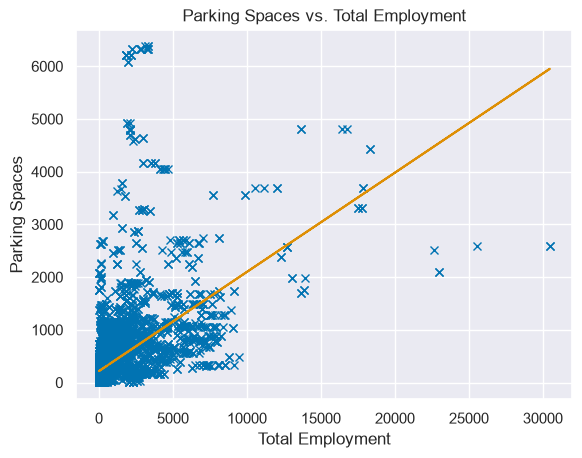

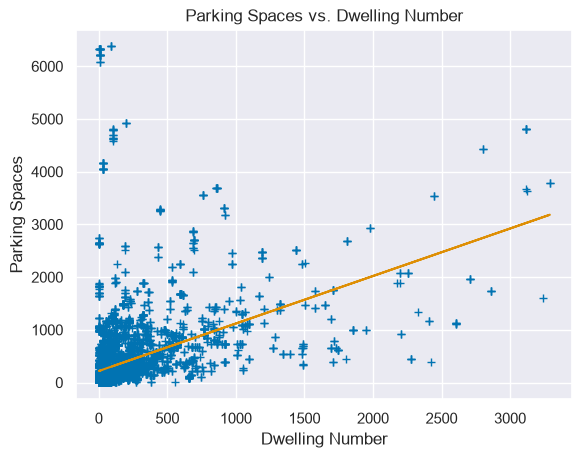

In [7]:
#Combine the datasets (only take the blocks that match between the three datasets)
data = resident_by_block.merge(employment_by_block, left_index= True, right_index=True)
data = data.merge(parking_by_block,left_index=True,right_index=True)
print(data.head())
#Prepare data for scatter plots
x1 = data['total_jobs_in_block']
x2 = data['dwelling_number']
y = data['parking_spaces']
#Plot the data points (Parking Spaces vs. Total Employment) and regression line
plt.plot(x1,y,'x')
a, b = np.polyfit(x1,y,1)
plt.plot(x1, a*x1 + b)
plt.title('Parking Spaces vs. Total Employment')
plt.ylabel('Parking Spaces')
plt.xlabel('Total Employment')
plt.show()
#Plot the data points (Parking Spaces vs. Dwelling Number) and regression line
plt.plot(x2,y,'+')
a, b = np.polyfit(x2,y,1)
plt.plot(x2, a*x2 + b)
plt.title('Parking Spaces vs. Dwelling Number')
plt.ylabel('Parking Spaces')
plt.xlabel('Dwelling Number')
plt.show()

#NOTE: This dataset ('data') needs to be exported to GitHub as a CSV named "merged_data.csv"
#inside a folder named "UC00027_dependencies" to allow the interactivity function below to work

In [16]:
data.to_csv('UC00027_dependencies/merged_data.csv')

We can notice the points below the orange regression lines are likely to have insufficient car parking.

<div class="usecase-section-header" id="model">3. Build analysis model</div>

This model uses multiple-variable linear regression. The model has dependent variable ***Y*** as "off-street car parking" and ***X1***, ***X2*** as "residential dwellings" and "employment by city block" respectively.

### Prepare the data for model training

In [8]:
#Prepare X and Y data for model training
def Get_data(Data, Year_to_include, Employment, Resident_dwellings):
    features = np.array(['total_jobs_in_block', 'dwelling_number'])
    features_to_include = features[[Employment, Resident_dwellings]]  #Define the data features for the study
    data_to_include = Data.loc[min(Year_to_include):max(Year_to_include)]  #Get the wanted rows
    X = np.array(data_to_include[features_to_include])  #Get the independent variable(s) based on the selected features
    Y = np.array(data_to_include['parking_spaces'])  #Get the dependent variable
    return X, Y

### Build and evaluate the linear regression model

In [9]:
def lm_model(X, Y):
    """Fit a linear regression model after removing outliers with Isolation Forest,
    and print the R² and MAE of the fitted model on its training data."""
    iso = IsolationForest(contamination=0.1, random_state=42)  #outlier detector
    is_inlier = iso.fit_predict(X) != -1  #search for outliers

    lm = linear_model.LinearRegression()  #linear regression model
    lm.fit(X[is_inlier], Y[is_inlier])  #train the model excluding outliers

    #Evaluate the model on the (inlier) training data
    Y_pred = lm.predict(X[is_inlier])
    r2 = r2_score(Y[is_inlier], Y_pred)
    mae = mean_absolute_error(Y[is_inlier], Y_pred)
    print(f'Model evaluation on training data -> R²: {r2:.3f}, MAE: {mae:.1f} parking spaces')

    return lm

### Predict the parking problem based on the latest year (2020)

In [10]:
#Predict parking issue in 2020
def Get_predict_result(Data, Model, Employment, Residential_dwellings):
    data_latest = Data.loc[years.max]  #Get data of 2020
    features = np.array(['total_jobs_in_block', 'dwelling_number'])
    features_to_include = features[[Employment, Residential_dwellings]]  #Define the data features for the study
    result = np.round(Model.predict(np.array(data_latest[features_to_include])))  #Predict based on the selected features
    data_latest['Predict_parking'] = result.astype(int)  #Add result to the data
    impact = result - data_latest['parking_spaces']
    impact[impact>=0] = 100*(impact[impact>=0]/(max(impact[impact>=0])))  #Normalise the impact index (0-100)
    data_latest['Impact_index'] = impact.astype(int)  #Add impact index to the data
    return data_latest

<div class="usecase-section-header" id="visualise">4. Visualise the analytical results</div>

### Plot a bar chart of the predicted results

In [11]:
#Visualise the impacted city blocks
def bar_plot(Data, Impact_level):
    #Only visualise the blocks greater than the impact level
    plot_data = Data['Impact_index']  #Get only the data records with a higher impact level
    plt.figure(figsize=(13,len(plot_data)/3))
    plt.xlabel('Impact Index (Higher index indicates a more serious shortage of off-street parking)')
    plt.ylabel('Block ID of Melbourne city')
    plt.title('Impacted Blocks vs. Impact Index\n Shows impact index from '+str(Impact_level)+' to 100')
    plt.barh(plot_data.index.astype(str),plot_data.values)
    plt.show()

### Plot the map using Folium Choropleth

In [12]:
def plot_map(clue_data):
    #Load the csv and json data for map plotting
    json_file = open('UC00027_dependencies/clue_blocks.geojson')
    clue_geo = json.load(json_file)

    clue_data.reset_index(inplace=True)  #turn the index (block_id) into a column in the dataframe (clue_data)
    clue_data['block_id'] = clue_data['block_id'].astype(str)  #convert block_id to str, so that it is compatible with the json content

    #Create the initial map (CartoDB positron tiles - no API key required)
    fmap = folium.Map(location=[-37.811600, 144.964610],
              tiles='CartoDB positron',
              width='70%',
              height='100%',
              zoom_start=13)

    #Create the choropleth layer and add it to the map above
    choropleth = folium.Choropleth(
        geo_data=clue_geo,
        name='choropleth',
        data=clue_data,
        columns=['block_id','Impact_index'],
        key_on='feature.properties.block_id',
        fill_color='YlOrRd',
        fill_opacity=1,
        line_opacity=0.5,
        nan_fill_color='lightgray',
        nan_fill_opacity=0.2,
        highlight=True,
        legend_name='Impact index'
    ).add_to(fmap)

    #Add more layers and tooltips
    choropleth.geojson.add_child(folium.features.GeoJsonTooltip(['block_id','clue_area'],labels=True))
    return fmap

<div class="usecase-section-header" id="interactivity">5. Develop interactivity</div>

We use the standard *ipywidgets* library to add interactivity directly inside this notebook - no external server or extra deployment step is required to explore the results interactively while the notebook is running.

### Build interactive widgets using ipywidgets

In [13]:
#Create widgets to select the range of study years and display options
style = {'description_width': 'initial'}  #for long labels on the widgets
#Year-to-include slider
years = widgets.IntRangeSlider(value=[2002, 2020], min=2002, max=2020, step=1, description='Years to include:', style=style)
#Display option: impact level
show_impact = widgets.IntSlider(value=15, min=10, max=100, step=1, description='Impact index from:',style=style)
#Employment checkbox
chk_employment = widgets.Checkbox(value=True, description='Employment', indent=False)
#Residential Dwellings checkbox
chk_resident = widgets.Checkbox(value=True, description='Residential Dwellings', indent=False)

### Main function for interactivity

In [14]:
#Define function to execute when using the interactive tools
def show_interaction(Year_to_include, Employment, Residential_dwellings, Impact_level):
    data = pd.read_csv('UC00027_dependencies/merged_data.csv')  #the dataset that contains all THREE features (employment, resident & parking)
    data = data.rename(columns={"Census year": "census_year","Block ID": "block_id","CLUE small area":"clue_small_area","Dwelling number":"dwelling_number","Total employment in block":"total_jobs_in_block","Parking spaces":"parking_spaces"})
    data.set_index(['census_year','block_id'],inplace=True)  #Turn the data into a multi-indexed dataframe
    print('='*23)
    print('|DATA ANALYSIS RESULTS|')
    print('='*23)
    print('(NOTE: The city blocks without parking information available are ignored by our analysing model.)\n\n')
    if (not(Employment)) & (not(Residential_dwellings)):
        Employment = True  #Prevent both data features being unticked ==> Error
    #Get the filtered data for analysis
    X, Y = Get_data(data,Year_to_include,Employment,Residential_dwellings)
    #Build regression model
    lm = lm_model(X,Y)
    #Get the predicted results
    predict_results = Get_predict_result(data,lm, Employment, Residential_dwellings)
    predict_results = predict_results[predict_results['Impact_index']>=Impact_level]  #only plot city blocks that have a higher impact level

    #Plot the bar chart of the predicted results
    bar_plot(predict_results, Impact_level);
    #Show table of the impacted blocks in a detail table
    print('\n\n The table below shows the impacted blocks (limited parking) in order of the impact index.\n')
    display(predict_results.sort_values('Impact_index',ascending = False))
    #Plot the folium choropleth map
    print('The impacted city blocks can be seen via the map here:')
    display(plot_map(predict_results))

<div class="usecase-section-header" id="demo">Demo use case</div>

With interactivity, a city planner can try to spot the city blocks that are likely to have insufficient parking but have a high density of employment and residential dwellings. Underneath the code block below, there are interactivity options that can be selected to analyse the data.

>Interactivity options:
- ***Years to include*** - Determines the census data (by year) to be included in the analysis
- ***Employment check*** - Ticked to include the "Employment by city block" dataset in the analysis
- ***Residential Dwellings check*** - Ticked to include the "Residential Dwellings" dataset in the analysis
- ***Impact index from*** - Filters out the block areas that have a minor parking insufficiency problem (lower than the selected ***Impact index***)

Once all options have been selected, please click the "Start Analysing" button to analyse the data.

NOTE: If both ***Employment*** and ***Residential Dwellings*** are unchecked, ***Employment*** will be automatically used for the analysis.

In [15]:
#Display the interactive tools
interact_manual.opts['manual_name'] = 'Start Analysing'
interact_manual(show_interaction, Year_to_include=years, Employment=chk_employment, Residential_dwellings = chk_resident, Impact_level = show_impact);

interactive(children=(IntRangeSlider(value=(2002, 2020), description='Years to include:', max=2020, min=2002, …